# Heart Disease Diagnosis Model

## Part 2: Data pre-processing

Data pre-processing is a crucial step in data analysis because raw data is often incomplete, inconsistent, or contains errors that can negatively impact the accuracy and reliability of the analysis. Data-preprocessing will help enhancing predictive model performance by enabling well-prepared data to improve model efficiency, reduce training time, and enhance predictive accuracy.

Here's why data pre-processing is important:

1. **Removing noise and inconsistencies**: Raw data may contain errors, duplicate observations (rows), or irrelevant information that can distort analysis results. Cleaning the data ensures higher accuracy.

2. **Handling missing data**: Many datasets have missing values, which can lead to biased models or incorrect conclusions. Techniques like imputation or removing incomplete observations (rows) help maintain data integrity.

3. **Normalization and scaling**: Features with different units and scales can negatively affect some machine learning techniques, especially distance-based such as k-Nearest Neighbors (k-NN), Support Vector Machines (SVMs) and Logistic Regression. Standardization or normalization ensures fair comparisons and better model performance.

4. **Handling categorical features**: The overwhelming majority of machine learning techniques require numerical input. Encoding categorical features (e.g., one-hot encoding, ordinal encoding) makes them usable in models.

5. **Dealing with imbalanced data**: In classification problems, imbalanced target classes can lead to biased models. Techniques like oversampling, undersampling, or synthetic data generation (SMOTE) help create a more balanced dataset.

6. **Feature engineering**: Deleting features with low importance, creating meaningful new features or transforming existing ones can significantly improve model accuracy and predictive power.

7. **Feature selection / Feature extraction (Dimensionality reduction)**: Too many features can lead to overfitting and increased computation time. Methods like Recursive FEature Eliminination (RFE), Sequential Forward/Backward Feature Selection (SFS) for feature selection, and Principal Component Analysis (PCA), Singular Vector Decomposition, Linear Discriminant Analysis (LDA) for reducing dataset dimensionality can be considered.

By performing data pre-processing, analysts and data scientists ensure that models and analyses are based on high-quality, reliable data, leading to more accurate and meaningful insights.

### Creating multiple pre-processed dataset versions

Creating different dataset versions based on various pre-processing strategies is a great idea, especially when working on machine learning projects:

1. Different pre-processing strategies can impact model performance
    * Pre-processing methods such as  missing data imputation, encoding, scaling, feature selection, and outlier handling can significantly affect model performance.
    * Creating multiple dataset versions allows you to compare different pre-processing techniques and choose the best one for your problem.
2. Helps in finding the optimal feature representation
    * Some algorithms (e.g. distance-based algorithms that use the notion of distance to measure proximity and similarity) work better with standardized or normalized data (e.g., SVM, k-NN). Others, like tree-based models (Random Forest, XGBoost), don't require scaling.
    * Trying different transformations can improve model accuracy and generalization.
3. Avoids overfitting to a specific pre-processing method
    * If you rely on a single pre-processing approach, you might unknowingly introduce bias.
    * Testing different dataset versions ensures that the final model is robust and not overfitting to a particular data transformation.
4. Helps in understanding the impact of missing data handling
    * Different strategies like mean imputation, median imputation, k-NN imputation, or using an indicator variable can be tested.
    * Some approaches might work better depending on the dataset structure.
5. Provides insights into feature engineering choices
    * Experimenting with feature selection, interaction terms, and dimensionality reduction (e.g., PCA, SVD, LDA) can show which feature engineering techniques improve performance.
    * For example, one dataset version might use all features, while another might only keep the most important ones.

**How to Manage Different Dataset Versions?**
* Apply the same transformations on both the training and test dataset. 
* Store versions systematically, e.g., dataset_v1_scaled.csv, dataset_v2_imputed.csv, etc.
* Compare results using the same evaluation metrics (accuracy, precision, recall, F1-score, etc.).

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, PowerTransformer
from scipy.stats import boxcox, yeojohnson
from scipy.special import inv_boxcox
from category_encoders import OrdinalEncoder, OneHotEncoder
from sklearn.decomposition import PCA
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, classification_report, make_scorer, f1_score
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

#### Loading the dataset

In [2]:
# Load Heart Disease UCI dataset
df = pd.read_csv("heart_disease_uci.csv")
df

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


#### Dataset cleaning: Handling duplicates

In [3]:
# Count duplicate rows
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [4]:
# Remove duplicate rows and keep the first occurrence
df = df.drop_duplicates()

# Reset index after removal (optional)
#df = df.reset_index(drop=True)

#### Dataset cleaning: Handling missing values

In [5]:
# Check for missing values (in absolute numbers)
df.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [6]:
# Calculate missing value percentages
missing_percentage = df.isnull().sum() * 100 / len(df)

# Display only columns with missing values
missing_percentage[missing_percentage > 0]

trestbps     6.413043
chol         3.260870
fbs          9.782609
restecg      0.217391
thalch       5.978261
exang        5.978261
oldpeak      6.739130
slope       33.586957
ca          66.413043
thal        52.826087
dtype: float64

Observations:

* features *slope*, *ca*, and *thal* have many missing values (both in absolute numbers and as a percentage).
* features *trestbps*, *chol*, *fbs*, *thalch*, *exang*, and *oldpeak* have some missing values.

Suggested strategies:

* Drop columns with excessive missing values (e.g., *ca* and *thal*).
* Impute numerical columns with the median or mean.
* Impute categorical columns with the most popular value or the mode or create an "Unknown" category.

You should consider dropping a column in your dataset when:

1. **High percentage of missing values**:
   * If a column has too many missing values (e.g., >50% missing), it might be better to remove it rather than impute it.
   * Exception: If the column is important and you can impute missing values meaningfully, keep it.
3. **Low variability (constant or near-constant values)**:
   * If a column has the same value for almost all rows, it doesn't contribute to the model.
   * Example: A column where 99% of values are "Yes" and only a few are "No."
4. **High correlation with another feature**:
    * If two columns are highly correlated (e.g., correlation > 0.9), one of them is redundant and can be dropped.
    * Use correlation heatmaps or VIF (Variance Inflation Factor) to check for multicollinearity.
5. **Irrelevant to the problem statement**:
    * If a column doesn't contribute to the target variable, it can be removed.
    * Example: "Customer ID" or "Timestamp" in a classification task.

##### Drop columns with excessive missing values

In [7]:
df = df.drop(columns=['ca', 'thal'])

#### Separate dataset into features (X) and target variable (y)

We should split your dataset into features (X) and target variable (y) early in the preprocessing pipeline, right after loading and basic cleaning. 

In [8]:
# Split features and target
X = df.drop(columns=['id', 'num']) # delete also id which is useless
y = df['num']

#### Data splitting

Splitting the original dataset into training and test sets is crucial for building a reliable machine learning model in order to:

1. Evaluate model performance on unseen Data
    * The goal of a machine learning model is to make accurate predictions on new, unseen data (not just the data it was trained on).
    * By keeping a test set separate, we can measure how well the model generalizes beyond the training data.

2. Prevent overfitting (data leakage risk)
    * If the model is trained on the entire dataset, it might memorize patterns instead of learning general rules.
    * A separate test set ensures we can detect overfitting, where the model performs well on training data but poorly on unseen data.

2. Tune and compare models
    * Different models (e.g., Decision Trees, SVMs) can be trained on the same training set and evaluated on the same test set to compare their performance fairly.
    * This helps in choosing the best model for real-world applications.

3. Simulate real-world scenarios
    * The test set acts as a simulation of future data.
    * Since a deployed model will make predictions on new data, testing it on unseen samples helps ensure it will perform well in practical applications.

**How to split the data?** 

Typical split: 80% training, 20% testing (or 70%-30% depending on dataset size).

If hyperparameter tuning is involved, a validation set is needed (e.g., 60% train, 20% validation, 20% test). Further dataset breakdown into validation dataset is usually internally handled by the cross-validation (CV) process.

**When to split the data?**

It's best to split the data into training and testing sets before applying preprocessing steps such as imputation, scaling and feature selection/extraction. This ensures that these transformations are based solely on the training data and then consistently applied separately to the test set.

The test data should be representative of real-world scenarios, meaning it should follow the same format and distribution as the data the model will encounter in production. This helps ensure that the model generalizes well and makes accurate predictions on unseen data.

If the dataset is split after preprocessing, there is a risk of data leakage, where information from the test set influences the training process. This can lead to overly optimistic performance estimates, making the model appear more effective than it actually is.

To sum up, data splitting before pre-processing steps:

* Avoids data leakage
    * If you compute statistics (e.g., mean for imputation or scaling) on the entire dataset before splitting, the test set indirectly influences the training set.
    * This makes the model look artificially better on the test data since knowledge from test set flows into the training dataset.
* Mimics real-world scenarios
    * In real-world applications, a model encounters new, unseen data and should generalize well.
    * The test set should reflect this by being processed using parameters from the training set.
* Consistent transformations
    * Preprocessing steps (like scaling and encoding) should be fitted only on the training set and applied to the test set.
 
**Is stratification needed when splitting?**
Stratification is important when splitting data whenever the target variable (y) is imbalanced or when class distribution matters for model performance. Here, the dataset is highly imbalalanced. Stratifying by y in train_test_split() ensures that the proportion of each class in the target variable remains the same in both the training and test sets. 

Example: Without Stratification: If y has 80% of class 0 and 20% of class 1, a random split might accidentally put most of the minority class (1s) in either train or test, leading to imbalanced splits.

In [9]:
# Split the data into training and test sets before scaling, encoding to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

Identify numerical and categorical features to apply appropriate imputing techniques and encoding on categorical only.

In [10]:
# Identify numerical and categorical features
num_features = X_train.select_dtypes(include=['int64', 'float64']).columns
print('Numerical columns', num_features)
cat_features = X_train.select_dtypes(include=['object']).columns
print('Categorical columns', cat_features)

Numerical columns Index(['age', 'trestbps', 'chol', 'thalch', 'oldpeak'], dtype='object')
Categorical columns Index(['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope'], dtype='object')


#### *Dataset V1*
1. Apply simple **imputer with mean strategy** on **numerical** features
2. Apply simple **imputer with most frequent strategy and ordinal encoding** on **categorical** (string-based) features

In [11]:
X_train_V_1 = X_train.copy()
X_test_V_1 = X_test.copy()

# Apply simple imputer with mean strategy on numerical features
si1 = SimpleImputer(strategy='mean')
# fit (train) imputer on the training dataset
si1.fit(X_train_V_1[num_features])
# apply imputation on both training and test datasets
X_train_V_1[num_features] = si1.transform(X_train_V_1[num_features])
X_test_V_1[num_features] = si1.transform(X_test_V_1[num_features])

# ALTERNATIVELY: you could fit and transform training data at the same time and then transform test data separately
#X_train_V_1[num_features] = si1.fit_transform(X_train_V_1[num_features])
#X_test_V_1[num_features] = si1.transform(X_test_V_1[num_features])

# Apply simple imputer with most_frequent strategy on categorical features
si2 = SimpleImputer(strategy='most_frequent')
si2.fit(X_train_V_1[cat_features])
X_train_V_1[cat_features] = si2.transform(X_train_V_1[cat_features])
X_test_V_1[cat_features] = si2.transform(X_test_V_1[cat_features])

# Apply ordinal encoding on categorical features
ordinal_encoder = OrdinalEncoder(return_df=True,
                                 handle_unknown='value',   # Handle unknown categories in the test set (at transform time) --> Encode unseen categories with -1
                                )
X_train_V_1[cat_features] = ordinal_encoder.fit_transform(X_train_V_1[cat_features])
X_test_V_1[cat_features] = ordinal_encoder.transform(X_test_V_1[cat_features])

#print(X_train_V_1)
#print(X_test_V_1)

##### Investigate feature selection techniques

If the number of features is relatively high, we can inverstigate whether feature selection and extraction can provide smaller feature sets which can reduce (a) computational costs during the training process of predictive modelling techniques as well as (b) reduce noise by discarding irrelevant or redundant features.

Feature selection should be performed after pre-processing—meaning after handling missing values, encoding categorical variables, scaling (if necessary), and ensuring only numerical features remain. The majority of feature selection techniques:
* correlation matrix (
* chi-square test
* feature importance using ensemble algorithms
* Recursive Feature Elimination (RFE)
* Forward/Backward Feature Selection)

require numerical features. Therefore, selecting features before encoding (and including only initial numerical features) might exclude valuable information.

**We should perform feature selection separately on each dataset version because different pre-processing steps (e.g., handling missing values, encoding, scaling, balancing, etc.) can affect feature relationships and importance. Scaling can affect feature magnitudes. Encoding categorical variables differently can influence correlations. Handling missing values in different ways can alter feature distributions. Thus, feature selection might yield different results for different dataset versions.**

In our example, the dataset is relatively small, thus there is no need to apply feature selection techniques. However, we will introduce the use of sequential forward selection (SFS) for educational purposes.

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   4 out of  12 | elapsed:   12.2s remaining:   24.6s
[Parallel(n_jobs=-1)]: Done  12 out of  12 | elapsed:   15.8s finished

[2025-03-14 16:12:17] Features: 1/12 -- score: 0.47055074865741997[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of  11 | elapsed:    4.1s remaining:   18.7s
[Parallel(n_jobs=-1)]: Done   8 out of  11 | elapsed:    4.5s remaining:    1.6s
[Parallel(n_jobs=-1)]: Done  11 out of  11 | elapsed:    6.9s finished

[2025-03-14 16:12:24] Features: 2/12 -- score: 0.4939790798209893[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   7 out of  10 | elapsed:    5.3s remaining:    2.2s
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:    7.5s finished

[2025-03-14 16:12:32] Features: 3/12 -- score: 0.5004963215703777[Parallel(n_jobs=-1)]: Using backend

best combination (ACC: 0.552): (2, 3, 6, 9, 10, 11)

all subsets:
 {1: {'feature_idx': (3,), 'cv_scores': array([0.46613672, 0.44601525, 0.52831997, 0.47411322, 0.4740991 ,
       0.43904842, 0.49724804, 0.47024478, 0.41762421, 0.49265778]), 'avg_score': 0.47055074865741997, 'feature_names': ('cp',)}, 2: {'feature_idx': (3, 6), 'cv_scores': array([0.52464229, 0.47285431, 0.5462626 , 0.49265323, 0.49524945,
       0.43904842, 0.49510763, 0.50012923, 0.46608902, 0.50775462]), 'avg_score': 0.4939790798209893, 'feature_names': ('cp', 'fbs')}, 3: {'feature_idx': (2, 3, 6), 'cv_scores': array([0.51610209, 0.44030062, 0.54680123, 0.52478691, 0.49878856,
       0.44437571, 0.4836259 , 0.51826087, 0.49479452, 0.5371268 ]), 'avg_score': 0.5004963215703777, 'feature_names': ('dataset', 'cp', 'fbs')}, 4: {'feature_idx': (2, 3, 6, 9), 'cv_scores': array([0.55325914, 0.457451  , 0.56673738, 0.55746554, 0.52542917,
       0.518747  , 0.51013557, 0.51342934, 0.49805854, 0.49804996]), 'avg_score': 0.51

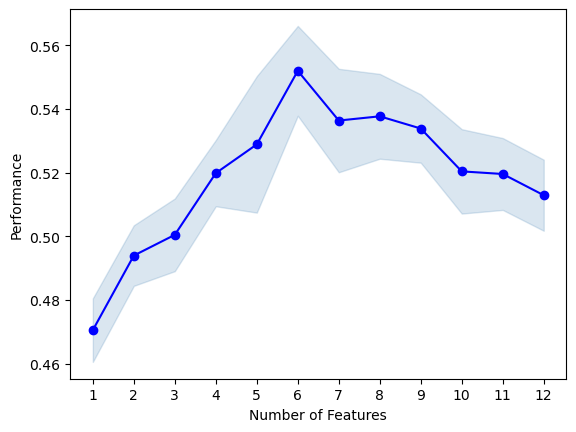

In [12]:
ada = AdaBoostClassifier(random_state=42)

# For scoring function, we will weighted F1 score since the dataset is unbalanced (as shown in EDA).
f1_score_weighted = make_scorer(f1_score, average='weighted')

# Sequential Forward Selection
sfs = SFS(ada, 
           k_features=(5,12), 
           forward=True, 
           floating=False, 
           verbose=2,
           scoring=f1_score_weighted,
           cv=10,
           n_jobs=-1)
           
sfs = sfs.fit(X_train_V_1, y_train)

print('best combination (ACC: %.3f): %s\n' % (sfs.k_score_, sfs.k_feature_idx_))
print('all subsets:\n', sfs.subsets_)
plot_sfs(sfs.get_metric_dict(), kind='std_err')
plt.show()

Based on the previous feature selection analysis, there is a smaleler featureset which achieves the highest performance (weighted F1 score).
Therefore, it is worth creating another dataset consisting of the best performing features.

#### *Dataset V2 (the "best performing" selected features from V1)*

1. Apply simple **imputer with mean strategy** on **numerical** features
2. Apply simple **imputer with most frequent strategy and ordinal encoding** on **categorical** (string-based) features
3. Sequential feature selection

In [13]:
#X_train_V_2 = sfs.transform(X_train_V_1) # this returns a numpy 2D array, not a pandas dataframe
X_train_V_2 = X_train_V_1.iloc[:, list(sfs.k_feature_idx_)]
X_test_V_2 = X_test_V_1.iloc[:, list(sfs.k_feature_idx_)]

###### Feature Extraction
Beyond feature selection, we can explore feature extraction using PCA. See version 7.

#### Handling imbalanced datasets

By examining the distribution of the target variable, we can check if the dataset is imbalanced. This was done in the first plot of the EDA and our dataset was found to be imbalanced.

Αn imbalanced dataset can lead to biased models that perform poorly on the minority class. In other words, if a model doesn't learn enough about the minority class, it won't generalize well to new, unseen data.

In imbalanced datasets, (the performance metric) accuracy can be misleading. Instead, handling imbalance allows us to use more meaningful metrics like:
* Precision & Recall: Focuses on how well the model identifies the minority class.
* F1-Score: Balances precision and recall.
* ROC-AUC Score: Evaluates the model’s ability to distinguish between classes.

In addition to using an appropriate metric when measuring a model's performance, we can balance the dataset using dedicate techniques:
* Oversampling e.g. SMOTE (Synthetic Minority Over-sampling Technique) to generate synthetic observations (rows) for the minority class
* Undersampling to remove excess observations (rows) from the majority class

The choice between SMOTE and undersampling depends not just on dataset size but also on the class imbalance ratio and total number of samples. Let's analyze both options based on general guidelines:
* SMOTE is best for small datasets (<10,000 rows) in order to avoid losing valuable data but generate additional observations.
* Undersampling is best for large datasets (>50,000 rows) because it discards observations. One of its main drawbacks is that it can discard useful data, leading to lower model performance.
* If your dataset is medium-sized (10,000 - 50,000 rows) you can try both SMOTE and undersampling and compare model performance.

#### *Dataset V3 (applying SMOTE on V1)*

1. Apply simple **imputer with mean strategy** on **numerical** features
2. Apply simple **imputer with most frequent strategy and ordinal encoding** on **categorical** (string-based) features
3. Apply SMOTE (oversampling) to balance the dataset

In [14]:
# Our dataset is very small (928 observations) therefore we will apply SMOTE. 
# We will keep both datasets, the original and the oversampled and train the model on both to compare the performance.

# Apply SMOTE on the training dataset
smote = SMOTE(random_state=42)
X_train_V_3, y_train_smote = smote.fit_resample(X_train_V_1, y_train)
X_test_V_3 = X_test_V_1.copy()

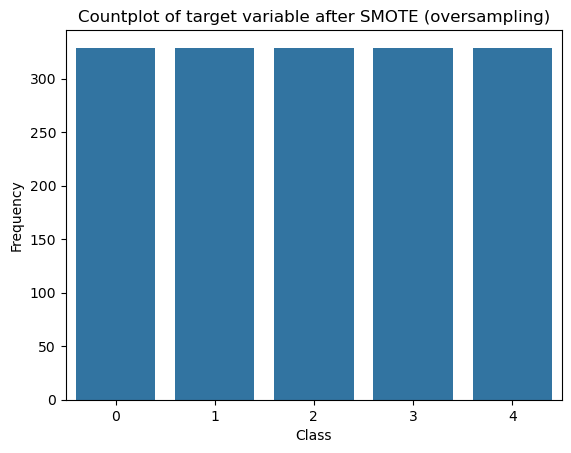

In [15]:
# Check new class distribution: it is expected that all classes have the same number samples
fig, ax = plt.subplots()
sns.countplot(x=y_train_smote)
ax.set_title("Countplot of target variable after SMOTE (oversampling)")
ax.set_xlabel("Class")
ax.set_ylabel("Frequency")
plt.show()

#### *Dataset V4 (the same as V1 + unskewing transformation on trestbps and oldpeak)*
1. Apply simple **imputer with mean strategy** on **numerical** features
2. Apply Yeo-Johnson **unskewing** on trestbps and oldpeak which were shown to be right skewed in EDA (we could apply Box-Cox if all data were positive; oldpeak column contains zero values)
3. Apply simple **imputer with most frequent strategy and ordinal encoding** on **categorical** (string-based) features

**Unskewing techniques**:
* Improve Model Performance: Many machine learning models assume that numerical features are normally distributed. A skewed distribution can negatively impact algorithms like linear regression, logistic regression, and k-NN.
* Reduce the Impact of Outliers: Right-skewed features often have extreme values that can distort model predictions.

In [16]:
X_train_V_4 = X_train_V_1.copy()
X_test_V_4 = X_test_V_1.copy()

# Initialize the PowerTransformer with Yeo-Johnson method
transformer = PowerTransformer(method='yeo-johnson')
# apply on trestbps and oldpeak
features_to_unskew = ['trestbps', 'oldpeak']
X_train_V_4[features_to_unskew] = transformer.fit_transform(X_train_V_4[features_to_unskew])  # Fit and transform training data (trestbps and oldpeak columns only)
X_test_V_4[features_to_unskew] = transformer.transform(X_test_V_4[features_to_unskew])  # Transform test data

#print(X_train_V_4)
#print(X_test_V_4)

#### *Dataset V5 (the same as V4 + scaling transformation)*
1. Apply simple **imputer with mean strategy** on **numerical** features
2. Apply Yeo-Johnson **unskewing** on trestbps and oldpeak which were shown to be right skewed in EDA (we could apply Box-Cox if all data were positive; oldpeak column contains zero values)
3. Apply **scaling** on the rest numerical continuous features that were not unskewed
4. Apply simple **imputer with most frequent strategy and ordinal encoding** on **categorical** (string-based) features

**Scaling techniques**:
* Prevent features with large magnitudes from dominating: Some algorithms (e.g., k-NN, SVM, logistic regression) are sensitive to feature magnitudes. Features with larger values can dominate the learning process, making smaller-valued features less significant.
* Improve model convergenceL gradient-based algorithms (e.g., logistic regression, neural networks) converge faster when features are on a similar scale.
* Enhances distance-based algorithms: k-Nearest Neighbors (k-NN) and clustering methods (e.g., K-Means) rely on distance calculations. If features are on different scales, the model will be biased towards those with larger ranges.
* Ensures fair weighting: In regularized models (e.g., Ridge, Lasso), scaling prevents one feature from disproportionately affecting the penalty term.

In [17]:
X_train_V_5 = X_train_V_4.copy()
X_test_V_5 = X_test_V_4.copy()

# Apply standard scaling on age, chol and thalch
# The aforementioned features seem to follow a roughly normal distribution (bell-shaped) as shown in EDA 
# (in distribution of numerical features). Therefore Standard scaler is appropriate. 
# Robust scaler could be used though since chol seems to have some outlier values as shown in EDA (in box plots of numerical features). 
# We prefer to apply the Standard scaler which is more suitable methods if we expect to apply PCA for dimensionality reduction.
rs = StandardScaler()
features_to_scale = ['age', 'chol', 'thalch']
rs.fit(X_train_V_5[features_to_scale])
X_train_V_5[features_to_scale] = rs.transform(X_train_V_5[features_to_scale])
X_test_V_5[features_to_scale] = rs.transform(X_test_V_5[features_to_scale])

#print(X_train_V_5)
#print(X_test_V_5)

#### *Dataset V6 (the same as V1 but one hot on categorical instead of ordinal)*
1. Apply simple **imputer with mean strategy** on **numerical** features
2. Apply simple **imputer with most frequent strategy and one hot encoding** on **categorical** (string-based) features

In [18]:
X_train_V_6 = X_train.copy()
X_test_V_6 = X_test.copy()

# Apply simple imputer with mean strategy on numerical features
si1 = SimpleImputer(strategy='mean')
# fit (train) imputer on the training dataset
si1.fit(X_train_V_6[num_features])
# apply imputation on both training and test datasets
X_train_V_6[num_features] = si1.transform(X_train_V_6[num_features])
X_test_V_6[num_features] = si1.transform(X_test_V_6[num_features])

# Apply simple imputer with most_frequent strategy on categorical features
si2 = SimpleImputer(strategy='most_frequent')
si2.fit(X_train_V_6[cat_features])
X_train_V_6[cat_features] = si2.transform(X_train_V_6[cat_features])

# Apply one hot encoding on categorical features
onehot_encoder = OneHotEncoder(return_df=True,
                                 handle_unknown='value',   # Handle unknown categories in the test set (at transform time) --> Encode a new value as 0 in every dummy column
                                )
new_cols_train = onehot_encoder.fit_transform(X_train[cat_features])
# Concatenate the original DataFrame with the encoded DataFrame
X_train_V_6 = pd.concat([X_train_V_6, new_cols_train], axis=1)
# Drop the original categorical column if you no longer need it
X_train_V_6 = X_train_V_6.drop(columns=cat_features)

new_cols_test = onehot_encoder.transform(X_test[cat_features])
X_test_V_6 = pd.concat([X_test_V_6, new_cols_test], axis=1)
X_test_V_6 = X_test_V_6.drop(columns=cat_features)

#print(X_train_V_6)
#print(X_test_V_6)

#### *Dataset V7* (the same as V5 + PCA)
1. Apply simple **imputer with mean strategy** on **numerical** features
2. Apply Yeo-Johnson **unskewing** on trestbps and oldpeak which were shown to be right skewed in EDA (we could apply Box-Cox if all data were positive; oldpeak column contains zero values)
3. Apply **scaling** on the rest numerical continuous features that were not unskewed
4. Apply simple **imputer with most frequent strategy and ordinal encoding** on **categorical** (string-based) features
5. PCA for feature extraction (dimensionality reduction)

Dimensionality Reduction

We use dimensionality reduction (a) if we have high-dimensional data and want to reduce redundancy, (b) if our dataset suffers from multicollinearity (correlated features), (c) to improve model training speed and reduce overfitting and (d) for visualization purposes in lower dimensions (e.g., 2D/3D plots).

It is not needed (a) if we need interpretability (PCA/SVD create transformed features that may not be human-readable), and (b) if our model can handle multicollinearity without issues (e.g., tree-based models like Random Forest or XGBoost).

it is appropriate and often necessary to run PCA (Principal Component Analysis) after scaling because PCA is sensitive to feature magnitudes. If the features are on different scales, PCA will give more importance to features with larger variances, leading to biased principal components. SVD does not strictly require scaling, but it often benefits from it.

In classification problems, we can also apply Linear Discriminant Analysis (LDA) which maximizes class separability by projecting data onto new axes (dimensions) and it is good for improving classification when classes are well-separated.

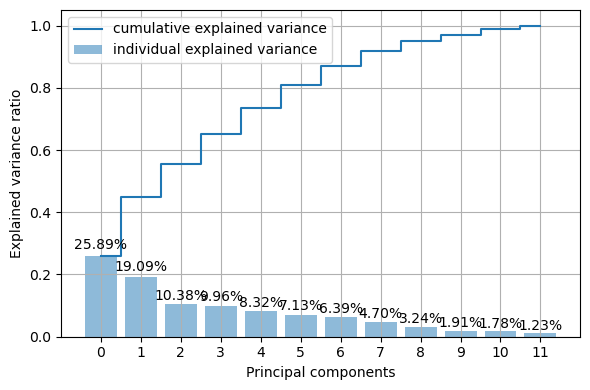

In [19]:
X_train_V_7 = X_train_V_5.copy()
X_test_V_7 = X_test_V_5.copy()

# function that plots the variance explained by each new feature
def print_variance_explained_plot(obj, n_components):
    cum_var_exp = np.cumsum(obj.explained_variance_ratio_)
    fig, ax = plt.subplots(figsize=(6, 4))
    bars = ax.bar(range(n_components), obj.explained_variance_ratio_, alpha=0.5, align='center',
                label='individual explained variance')
    # show percentage of explained variance on top of each bar
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., 1.05*height, '%.2f%%' % (height*100), 
                ha='center', va='bottom')
    plt.step(range(n_components), cum_var_exp, where='mid',
                 label='cumulative explained variance')
    plt.ylabel('Explained variance ratio')
    plt.xlabel('Principal components')
    plt.xticks( range(n_components) )
    plt.grid(True)
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

pca = PCA(n_components=12)
pca.fit(X_train_V_7)
print_variance_explained_plot(pca, 12)

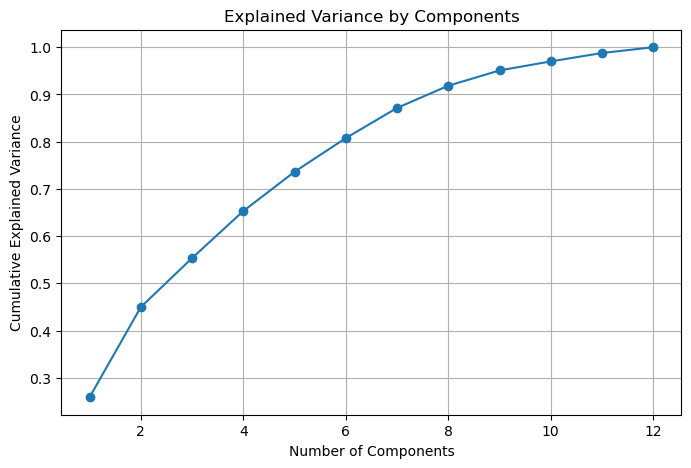

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_.cumsum(), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by Components')
plt.grid()
plt.show()

In [21]:
#  Choose an adequate number of components to achieve cumulative variance ~ 90-95%
# 80%-90%: Often sufficient in many real-world cases, balancing dimensionality reduction and retaining meaningful information.
# >95%: For datasets where preserving most information is critical, such as scientific or engineering applications.
# <80%: In cases where some loss of information is acceptable, such as when working with very large datasets and prioritizing computational efficiency.

pca = PCA(n_components=12)
X_train_V_7 = pca.fit_transform(X_train_V_7)
X_test_V_7 = pca.transform(X_test_V_7)

#print(X_train_V_7)
#print(X_test_V_7)